<a href="https://colab.research.google.com/github/tsholofelo-mokheleli/Shift-Aware-Explainable-Machine-Learning/blob/main/SAXML-Model%20Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Shift-Aware Explainable Machine Learning - Model Development**

### **LIBRARY LOADING**

In [256]:
# Load the libraries
import pandas  as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time
import psutil
import os

# Filter warnings
import warnings
warnings.filterwarnings('ignore')

# Theme
sns.set_theme(style="ticks")
colors = sns.color_palette("Pastel1", n_colors=3)

# Metrics
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.ensemble import RandomForestClassifier # Random Forest
from xgboost import XGBClassifier # Extreme Gradient Boosting (XGBoost)

from sklearn.linear_model import SGDClassifier

# Hyper-parameter tuning
from sklearn.model_selection import GridSearchCV

# Cross Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Scaling
from sklearn.preprocessing import StandardScaler

# Explainability
import shap

from sklearn.inspection import partial_dependence

### **DATA LOADING**

In [257]:
mh_training = pd.read_csv('mh_training_cleaned.csv')
mh_validation = pd.read_csv('mh_validation_cleaned.csv')
mh_testing = pd.read_csv('mh_testing_cleaned.csv')

In [258]:
mh_training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1948 entries, 0 to 1947
Data columns (total 36 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Diagnosed_mh                                  1948 non-null   int64
 1   Self_employed                                 1948 non-null   int64
 2   Company_size                                  1948 non-null   int64
 3   Employer_tech                                 1948 non-null   int64
 4   Ease_medical_leave                            1948 non-null   int64
 5   Employer_importance_mental                    1948 non-null   int64
 6   Coworker_reaction                             1948 non-null   int64
 7   Sought_treatment                              1948 non-null   int64
 8   Interference_work_effective_treatment         1948 non-null   int64
 9   Interference_work_no_treatment                1948 non-null   int64
 10  Age         

### **LEAKAGE AUDIT AND DATA SPLITTING**

The goal of this study is to build a model that can predict a diagnosis ($\mathbf{Diagnosed\_mh}$) using information available before the diagnostic event. This is known as a prospective screening scenario. Including features that are a consequence of the diagnosis leads to target leakage, artificially inflating model performance and rendering the results useless for real-world risk assessment.

In [259]:
leakage_features_to_drop = [
    'Sought_treatment',
    'Interference_work_effective_treatment',
    'Interference_work_no_treatment',
]

try:
    mh_training = mh_training.drop(columns=leakage_features_to_drop, errors='ignore')
    mh_validation = mh_validation.drop(columns=leakage_features_to_drop, errors='ignore')
    mh_testing = mh_testing.drop(columns=leakage_features_to_drop, errors='ignore')
    print("SUCCESS")

except NameError:
    print("ERROR")

SUCCESS


In [260]:
TARGET = 'Diagnosed_mh'

X_train, y_train = mh_training.drop(columns=[TARGET]), mh_training[TARGET]
X_val, y_val = mh_validation.drop(columns=[TARGET]), mh_validation[TARGET]
X_test, y_test = mh_testing.drop(columns=[TARGET]), mh_testing[TARGET]

### **Data Preparation**

#### **Check Class distrubution**

In [261]:
print(mh_training['Diagnosed_mh'].value_counts().sort_index())

Diagnosed_mh
0     729
1    1219
Name: count, dtype: int64


We will use **Class Weights** by passing `class_weight='balanced'` to your $\text{LR-EN}$ model and the calculated `scale_pos_weight` to your $\text{XGBoost}$ model during your hyperparameter tuning.

#### **Feature Scaling**

Scale your numerical features, fitting the scaler only on the training set to prevent data leakage. This is non-negotiable for your $\text{LR-EN}$ model.

In [262]:
features_to_scale = [
    'Age',
    'Company_size',
    'Ease_medical_leave',
    'Employer_importance_mental',
    'Coworker_reaction'
]

scaler = StandardScaler()
scaler.fit(X_train[features_to_scale])

X_train[features_to_scale] = scaler.transform(X_train[features_to_scale])
X_val[features_to_scale]   = scaler.transform(X_val[features_to_scale])
X_test[features_to_scale]  = scaler.transform(X_test[features_to_scale])

### **MODEL DEFINITION AND HYPERPARAMETER TUNING**

#### **Calculate Class Weights**

For XGBoost, we need the ratio of negative to positive samples `(scale_pos_weight)`. For the $\text{LR-EN}$ model, we'll use the `'balanced'` setting.

In [263]:
count_neg = y_train.value_counts()[0]
count_pos = y_train.value_counts()[1]
xgb_scale_pos_weight = count_neg / count_pos

print(xgb_scale_pos_weight)

0.5980311730926989


#### **LR-EN Tuning**

In [264]:
# Model: Uses SGDClassifier with log_loss for Logistic Regression
lr_en = SGDClassifier(
    loss='log_loss',
    penalty='elasticnet',
    class_weight='balanced',     # Handles class imbalance
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

# Hyperparameter search space for Elastic Net (L1 and L2 mix)
param_grid_lr = {
    'alpha': [0.0001, 0.001, 0.01],   # Regularization strength
    'l1_ratio': [0.1, 0.5, 0.9],      # Mix: 0.1=mostly L2 (Ridge), 0.9=mostly L1 (Lasso)
}

# Use Grid Search on the training data (X_train, y_train)
grid_search_lr = GridSearchCV(
    estimator=lr_en,
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=3,
    verbose=0
)
grid_search_lr.fit(X_train, y_train)
best_lr_en = grid_search_lr.best_estimator_

#### **XGBoost Tuning**

In [265]:
# Model: Incorporates the calculated scale_pos_weight
xgb = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=xgb_scale_pos_weight, # Handles class imbalance
    random_state=42
)

# Hyperparameter search space for XGBoost (focused on complexity and learning rate)
param_grid_xgb = {
    'n_estimators': [100, 200],       # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Max depth of trees
    'learning_rate': [0.05, 0.1, 0.2] # Step size shrinkage
}

# Use Grid Search on the training data (X_train, y_train)
grid_search_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=3,
    verbose=0
)
grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_

#### **Random Forest Tuning**

In [266]:
# We use 'class_weight="balanced"' to handle the class imbalance.
rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

# Focus on key parameters that control complexity and overfitting
param_grid_rf = {
    'n_estimators': [100, 200],       # Number of trees in the forest
    'max_depth': [10, 20],            # Maximum depth of the trees
    'min_samples_split': [5, 10]      # Minimum number of samples required to split an internal node
}

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=3,
    verbose=0
)
# Fit the grid search on the training data
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_

In [267]:
print("\nModel Tuning Complete:")
print(f"LR-EN Best Params: {grid_search_lr.best_params_}")
print(f"XGBoost Best Params: {grid_search_xgb.best_params_}")
print(f"Random Forest Best Params: {grid_search_rf.best_params_}")


Model Tuning Complete:
LR-EN Best Params: {'alpha': 0.001, 'l1_ratio': 0.5}
XGBoost Best Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100}
Random Forest Best Params: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}


### **FINAL ANALYSIS: TEMPORAL DRIFT**

#### **Quantify Temporal Drift**

In [268]:
models = {
    'LR-EN': best_lr_en,
    'XGBoost': best_xgb,
    'Random Forest': best_rf
}

# Evaluate performance on the final, unseen Test Set (representing post-shift data)
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    # The printed Validation AUC provides the pre-shift baseline for comparison
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    print(f"{name}: Validation AUC (Pre-Shift) = {val_auc:.4f}, Test AUC (Post-Shift) = {auc:.4f}")
    print(f"  --> AUC Degradation: {val_auc - auc:.4f}")


LR-EN: Validation AUC (Pre-Shift) = 0.6343, Test AUC (Post-Shift) = 0.7748
  --> AUC Degradation: -0.1406
XGBoost: Validation AUC (Pre-Shift) = 0.6204, Test AUC (Post-Shift) = 0.8170
  --> AUC Degradation: -0.1967
Random Forest: Validation AUC (Pre-Shift) = 0.6343, Test AUC (Post-Shift) = 0.8089
  --> AUC Degradation: -0.1746


#### **Transparent Risk Factor Identification**

In [269]:
# Access the LR-EN model's coefficients
coefficients = best_lr_en.coef_[0]
feature_names = X_test.columns

# Calculate Odds Ratios: OR = e^(coefficient)
odds_ratios = np.exp(coefficients)

# Combine features and ORs into a DataFrame for easy reporting
lr_results = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': odds_ratios
}).sort_values(by='Odds_Ratio', ascending=False)

# Display the top and bottom predictors (risk and protective factors)
print("Top 10 Risk Factors (Highest Odds Ratio):")
print(lr_results.head(10).to_markdown(index=False, floatfmt=".3f"))
print("\nTop 10 Protective Factors (Lowest Odds Ratio):")
print(lr_results.sort_values(by='Odds_Ratio', ascending=True).head(10).to_markdown(index=False, floatfmt=".3f"))

Top 10 Risk Factors (Highest Odds Ratio):
| Feature                                      |   Coefficient |   Odds_Ratio |
|:---------------------------------------------|--------------:|-------------:|
| Family_history_Yes                           |         1.588 |        4.896 |
| Anonymity_protected_Yes                      |         0.700 |        2.013 |
| Observed_unsupportive_Yes                    |         0.653 |        1.922 |
| Prev_emp_benefits_Yes, they all did          |         0.469 |        1.599 |
| Comfort_coworkers_Yes                        |         0.465 |        1.593 |
| Know_mh_options_Yes                          |         0.424 |        1.528 |
| Gender_Other                                 |         0.389 |        1.476 |
| Prev_options_Yes, I was aware of all of them |         0.345 |        1.411 |
| Age                                          |         0.287 |        1.332 |
| Mh_benefits_Yes                              |         0.265 |        1.304 

#### **Population Stability Index (PSI) (pre vs post)**

PSI is the gold standard in data drift literature.

This directly answers:
> *How do the risk factors change over time?*

Interpretation guideline:
- PSI < 0.1 → stable
- PSI 0.1–0.25 → moderate drift
- PSI > 0.25 → severe drift (world changed!)

In [270]:
def calculate_psi(expected, actual, bins=10):

    expected = pd.Series(expected).dropna()
    actual = pd.Series(actual).dropna()

    # If binary / low-unique categorical: treat as categories
    if expected.nunique() <= 5:
        # align categories
        cats = sorted(set(expected.unique()) | set(actual.unique()))
        expected_dist = expected.value_counts(normalize=True).reindex(cats).fillna(0)
        actual_dist   = actual.value_counts(normalize=True).reindex(cats).fillna(0)
    else:
        # numeric: use quantile-based binning on expected
        breakpoints = np.nanpercentile(expected, np.linspace(0, 100, bins + 1))
        breakpoints[0] -= 1e-6   # ensure min included
        breakpoints[-1] += 1e-6  # ensure max included

        expected_bins = pd.cut(expected, bins=breakpoints, duplicates='drop')
        actual_bins   = pd.cut(actual,   bins=breakpoints, duplicates='drop')

        expected_dist = expected_bins.value_counts(normalize=True).sort_index()
        actual_dist   = actual_bins.value_counts(normalize=True).sort_index()

    # avoid division by zero / log(0)
    expected_dist = expected_dist.replace(0, 1e-6)
    actual_dist   = actual_dist.replace(0, 1e-6)

    psi_values = (actual_dist - expected_dist) * np.log(actual_dist / expected_dist)
    return psi_values.sum()

# ---- Compute PSI for all features: X_val (pre) vs X_test (post) ----
psi_scores = {}

for col in X_val.columns:
    psi_scores[col] = calculate_psi(X_val[col], X_test[col], bins=10)

psi_df = pd.DataFrame.from_dict(psi_scores, orient='index', columns=['PSI']) \
                     .sort_values('PSI', ascending=False)

print("Top 10 most shifted features by PSI:")
print(psi_df.head(20))

Top 10 most shifted features by PSI:
                                          PSI
Ease_medical_leave                   0.829971
Mh_resources_Yes                     0.574693
Employer_discussed_mh_Yes            0.448946
Age                                  0.233767
Coworker_reaction                    0.169882
Employer_importance_mental           0.122495
Company_size                         0.080773
Anonymity_protected_Yes              0.076042
Self_employed                        0.074410
Prev_resources_Yes, they all did     0.062476
Prev_discussed_mh_Yes, they all did  0.061596
Comfort_coworkers_Yes                0.044324
Willing_interview_Yes                0.042938
Mh_benefits_Not Eligible             0.038220
Gender_Other                         0.038220
Comfort_supervisor_Yes               0.032082
Observed_unsupportive_Yes            0.024419
Willing_physical_Yes                 0.022328
Mh_benefits_No                       0.014299
Prev_anonymity_Yes, always           0.0137

<Figure size 2100x1800 with 0 Axes>

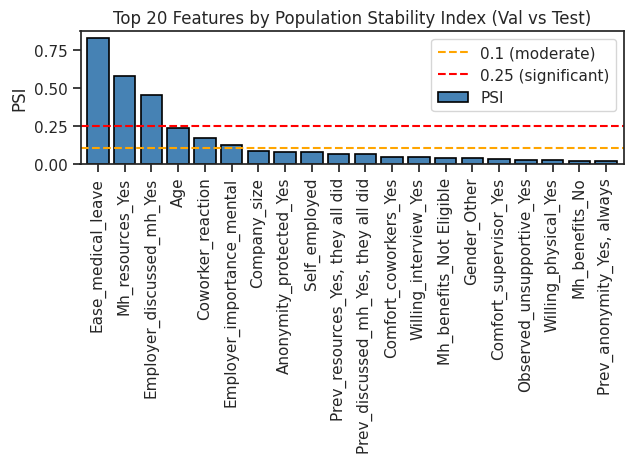

In [271]:
plt.figure(figsize=(14, 12), dpi=150)

ax = psi_df.sort_values('PSI', ascending=False).head(20).plot(
    kind='bar',
    width=0.8,
    color='steelblue',
    edgecolor='black',
    linewidth=1.2,
)

plt.axhline(0.1, color='orange', linestyle='--', label='0.1 (moderate)')
plt.axhline(0.25, color='red', linestyle='--', label='0.25 (significant)')
plt.ylabel('PSI')
plt.title('Top 20 Features by Population Stability Index (Val vs Test)')
plt.legend()
plt.tight_layout()
plt.show()

#### **Threshold Sensitivity Curves**

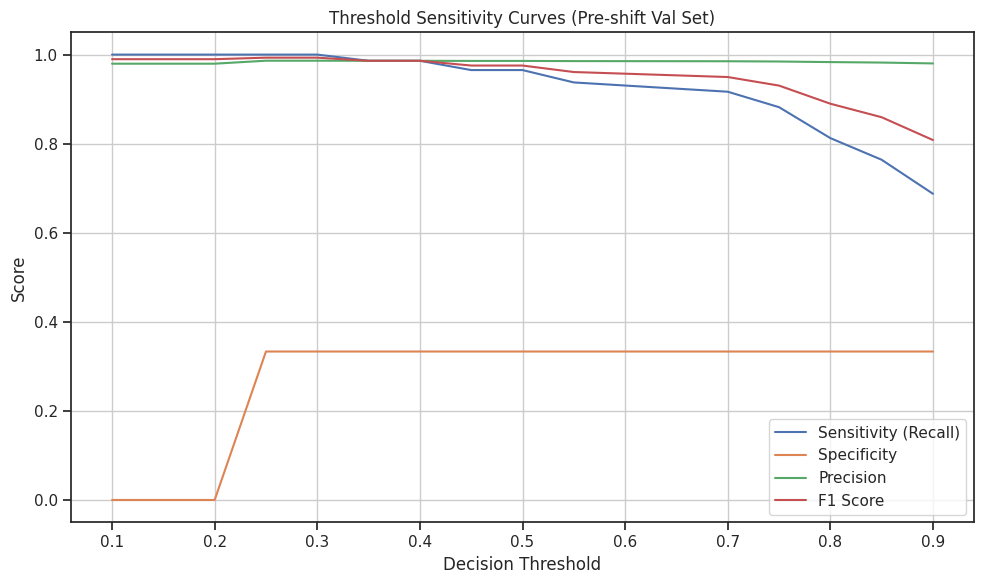

In [272]:
def threshold_sensitivity(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.1, 0.9, 17)

    records = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        recall    = recall_score(y_true, y_pred)            # sensitivity
        precision = precision_score(y_true, y_pred)
        f1        = f1_score(y_true, y_pred)

        # specificity = TN / (TN + FP)
        tn = np.sum((y_true == 0) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

        records.append({
            'threshold': t,
            'sensitivity': recall,
            'specificity': specificity,
            'precision': precision,
            'f1': f1
        })
    return pd.DataFrame(records)

y_val_proba  = best_xgb.predict_proba(X_val)[:, 1]
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]

ts_val  = threshold_sensitivity(y_val,  y_val_proba)
ts_test = threshold_sensitivity(y_test, y_test_proba)

# Plot sensitivity/specificity/F1 vs threshold for test set
plt.figure(figsize=(10,6))
plt.plot(ts_val['threshold'], ts_val['sensitivity'], label='Sensitivity (Recall)')
plt.plot(ts_val['threshold'], ts_val['specificity'], label='Specificity')
plt.plot(ts_val['threshold'], ts_val['precision'],   label='Precision')
plt.plot(ts_val['threshold'], ts_val['f1'],          label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Sensitivity Curves (Pre-shift Val Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

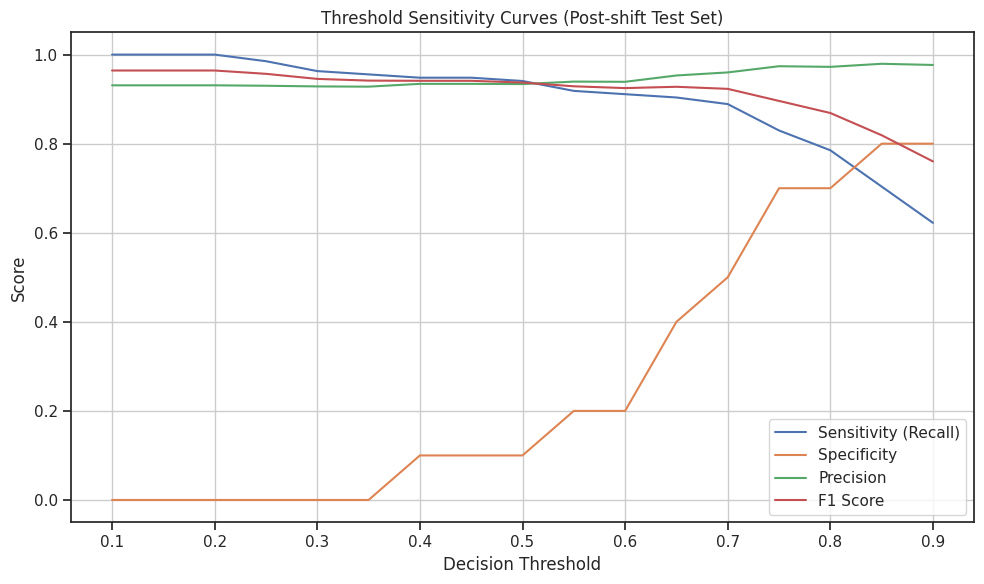

In [273]:
# Plot sensitivity/specificity/F1 vs threshold for test set
plt.figure(figsize=(10,6))
plt.plot(ts_test['threshold'], ts_test['sensitivity'], label='Sensitivity (Recall)')
plt.plot(ts_test['threshold'], ts_test['specificity'], label='Specificity')
plt.plot(ts_test['threshold'], ts_test['precision'],   label='Precision')
plt.plot(ts_test['threshold'], ts_test['f1'],          label='F1 Score')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Threshold Sensitivity Curves (Post-shift Test Set)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [274]:
print("Threshold sensitivity summary (Val):")
print(ts_val.to_markdown(index=False, floatfmt=".3f"))

Threshold sensitivity summary (Val):
|   threshold |   sensitivity |   specificity |   precision |    f1 |
|------------:|--------------:|--------------:|------------:|------:|
|       0.100 |         1.000 |         0.000 |       0.980 | 0.990 |
|       0.150 |         1.000 |         0.000 |       0.980 | 0.990 |
|       0.200 |         1.000 |         0.000 |       0.980 | 0.990 |
|       0.250 |         1.000 |         0.333 |       0.986 | 0.993 |
|       0.300 |         1.000 |         0.333 |       0.986 | 0.993 |
|       0.350 |         0.986 |         0.333 |       0.986 | 0.986 |
|       0.400 |         0.986 |         0.333 |       0.986 | 0.986 |
|       0.450 |         0.965 |         0.333 |       0.986 | 0.975 |
|       0.500 |         0.965 |         0.333 |       0.986 | 0.975 |
|       0.550 |         0.938 |         0.333 |       0.985 | 0.961 |
|       0.600 |         0.931 |         0.333 |       0.985 | 0.957 |
|       0.650 |         0.924 |         0.333 |      

In [275]:
print("Threshold sensitivity summary (Test):")
print(ts_test.to_markdown(index=False, floatfmt=".3f"))

Threshold sensitivity summary (Test):
|   threshold |   sensitivity |   specificity |   precision |    f1 |
|------------:|--------------:|--------------:|------------:|------:|
|       0.100 |         1.000 |         0.000 |       0.931 | 0.964 |
|       0.150 |         1.000 |         0.000 |       0.931 | 0.964 |
|       0.200 |         1.000 |         0.000 |       0.931 | 0.964 |
|       0.250 |         0.985 |         0.000 |       0.930 | 0.957 |
|       0.300 |         0.963 |         0.000 |       0.929 | 0.945 |
|       0.350 |         0.956 |         0.000 |       0.928 | 0.942 |
|       0.400 |         0.948 |         0.100 |       0.934 | 0.941 |
|       0.450 |         0.948 |         0.100 |       0.934 | 0.941 |
|       0.500 |         0.941 |         0.100 |       0.934 | 0.937 |
|       0.550 |         0.919 |         0.200 |       0.939 | 0.929 |
|       0.600 |         0.911 |         0.200 |       0.939 | 0.925 |
|       0.650 |         0.904 |         0.400 |     

#### **PDP Drift – Shape Change in Feature–Outcome Relationship**

Partial Dependence Difference (PDP-Δ)

This answers:
> *Did the relationship between the feature and diagnosis change shape?*

For example, age may be linearly increasing risk before, but flat afterward.

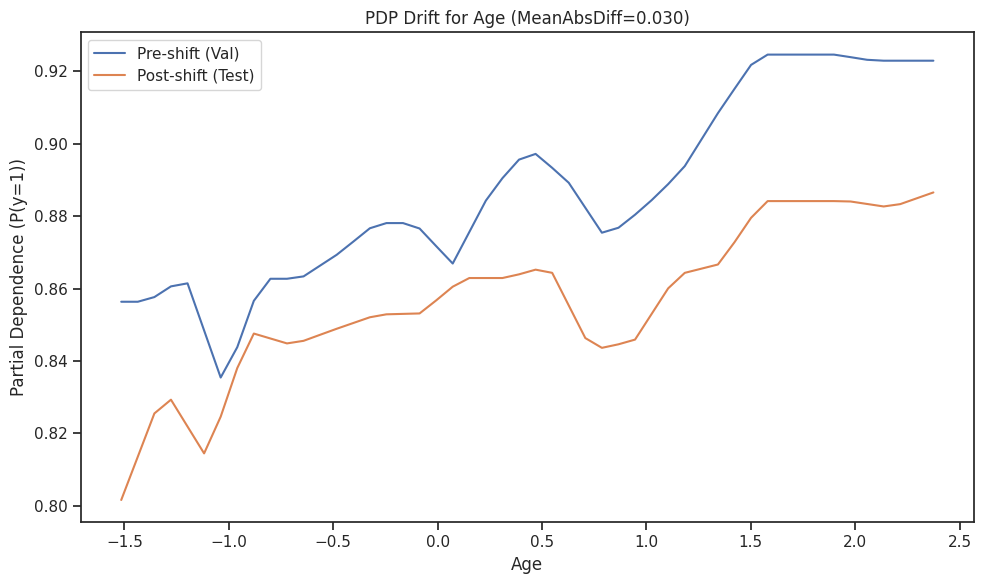

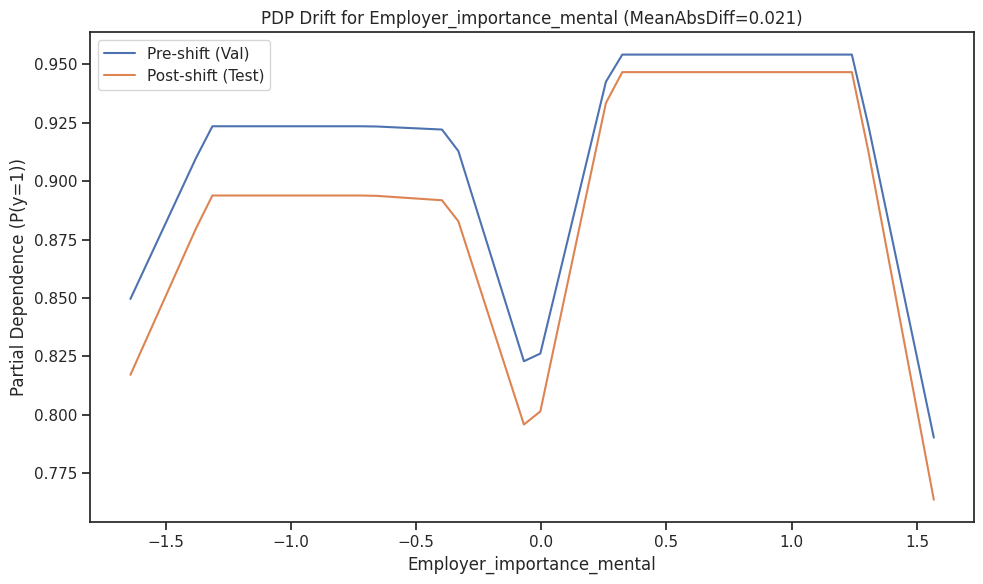

In [276]:
def pdp_curve(model, X, feature_name, grid_resolution=20):
    """Returns (grid, pdp_values) for a single feature."""
    feat_idx = list(X.columns).index(feature_name)
    pd = partial_dependence(model, X, [feat_idx], grid_resolution=grid_resolution)
    # pd['average'] shape: (1, grid_resolution)
    grid = pd['grid_values'][0] # Corrected from 'values'
    pdp_values = pd['average'][0]
    return grid, pdp_values

# Example: choose 3 key features to inspect
pdp_features = [
    'Age',
    'Employer_importance_mental'
]

pdp_drift_records = []

for feat in pdp_features:
    grid_pre,  pdp_pre  = pdp_curve(best_xgb, X_val,  feat)
    grid_post, pdp_post = pdp_curve(best_xgb, X_test, feat)

    # Interpolate onto a common grid in case they differ
    common_grid = np.linspace(min(grid_pre.min(),  grid_post.min()),
                              max(grid_pre.max(),  grid_post.max()), 50)
    pdp_pre_interp  = np.interp(common_grid, grid_pre,  pdp_pre)
    pdp_post_interp = np.interp(common_grid, grid_post, pdp_post)

    # simple numeric drift metric: mean absolute difference
    mad = np.mean(np.abs(pdp_post_interp - pdp_pre_interp))

    pdp_drift_records.append({
        'Feature': feat,
        'PDP_MeanAbsDiff': mad
    })

    # Plot
    plt.figure(figsize=(10,6))
    plt.plot(common_grid, pdp_pre_interp,  label='Pre-shift (Val)')
    plt.plot(common_grid, pdp_post_interp, label='Post-shift (Test)')
    plt.xlabel(feat)
    plt.ylabel('Partial Dependence (P(y=1))')
    plt.title(f'PDP Drift for {feat} (MeanAbsDiff={mad:.3f})')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [277]:
pdp_drift_df = pd.DataFrame(pdp_drift_records)
print("PDP Drift Summary:")
print(pdp_drift_df.to_markdown(index=False, floatfmt=".4f"))

PDP Drift Summary:
| Feature                    |   PDP_MeanAbsDiff |
|:---------------------------|------------------:|
| Age                        |            0.0301 |
| Employer_importance_mental |            0.0208 |


### **Explainability: SHAP Global Feature Importance**

#### **SHAP Value Shift Index**

This tells us:
> *Which features changed most in influence across time?*

This is a powerful “explainable drift” metric.

In [278]:
# Ensure explainer uses your tuned XGBoost model
explainer = shap.TreeExplainer(best_xgb)

# SHAP values pre-shift (validation) and post-shift (test)
shap_val   = explainer.shap_values(X_val)
shap_test  = explainer.shap_values(X_test)

# For binary classification, shap_values is (n_samples, n_features)
# Compute mean |SHAP| per feature
mean_abs_shap_val  = np.abs(shap_val).mean(axis=0)
mean_abs_shap_test = np.abs(shap_test).mean(axis=0)

shap_drift = mean_abs_shap_test - mean_abs_shap_val   # positive = more important post-shift

shap_drift_df = pd.DataFrame({
    'Feature': X_val.columns,
    'MeanAbsSHAP_Pre':  mean_abs_shap_val,
    'MeanAbsSHAP_Post': mean_abs_shap_test,
    'SHAP_Drift':       shap_drift
}).sort_values('SHAP_Drift', ascending=False)

print("Top 10 features whose importance increased post-shift:")
print(shap_drift_df.head(10).to_markdown(index=False, floatfmt=".4f"))

Top 10 features whose importance increased post-shift:
| Feature                             |   MeanAbsSHAP_Pre |   MeanAbsSHAP_Post |   SHAP_Drift |
|:------------------------------------|------------------:|-------------------:|-------------:|
| Prev_discussed_mh_Yes, they all did |            0.0419 |             0.0824 |       0.0404 |
| Ease_medical_leave                  |            0.0601 |             0.0987 |       0.0386 |
| Anonymity_protected_Yes             |            0.0500 |             0.0817 |       0.0316 |
| Comfort_coworkers_Yes               |            0.1975 |             0.2276 |       0.0301 |
| Willing_physical_Yes                |            0.0445 |             0.0611 |       0.0166 |
| Family_history_Yes                  |            0.6046 |             0.6188 |       0.0142 |
| Prev_emp_benefits_Yes, they all did |            0.0760 |             0.0895 |       0.0135 |
| Prev_anonymity_Yes, always          |            0.1042 |             0.1167 | 

In [279]:
print("Top 10 features whose importance decreased post-shift:")
print(shap_drift_df.sort_values('SHAP_Drift', ascending=True).head(20).to_markdown(index=False, floatfmt=".4f"))

Top 10 features whose importance decreased post-shift:
| Feature                                      |   MeanAbsSHAP_Pre |   MeanAbsSHAP_Post |   SHAP_Drift |
|:---------------------------------------------|------------------:|-------------------:|-------------:|
| Coworker_reaction                            |            1.3506 |             1.2163 |      -0.1343 |
| Employer_importance_mental                   |            0.9186 |             0.8810 |      -0.0376 |
| Observed_unsupportive_Yes                    |            0.2759 |             0.2414 |      -0.0345 |
| Gender_Other                                 |            0.0519 |             0.0342 |      -0.0177 |
| Mh_benefits_Not Eligible                     |            0.0312 |             0.0214 |      -0.0099 |
| Age                                          |            0.2272 |             0.2184 |      -0.0088 |
| Prev_options_No, I only became aware later   |            0.0789 |             0.0702 |      -0.0087 |


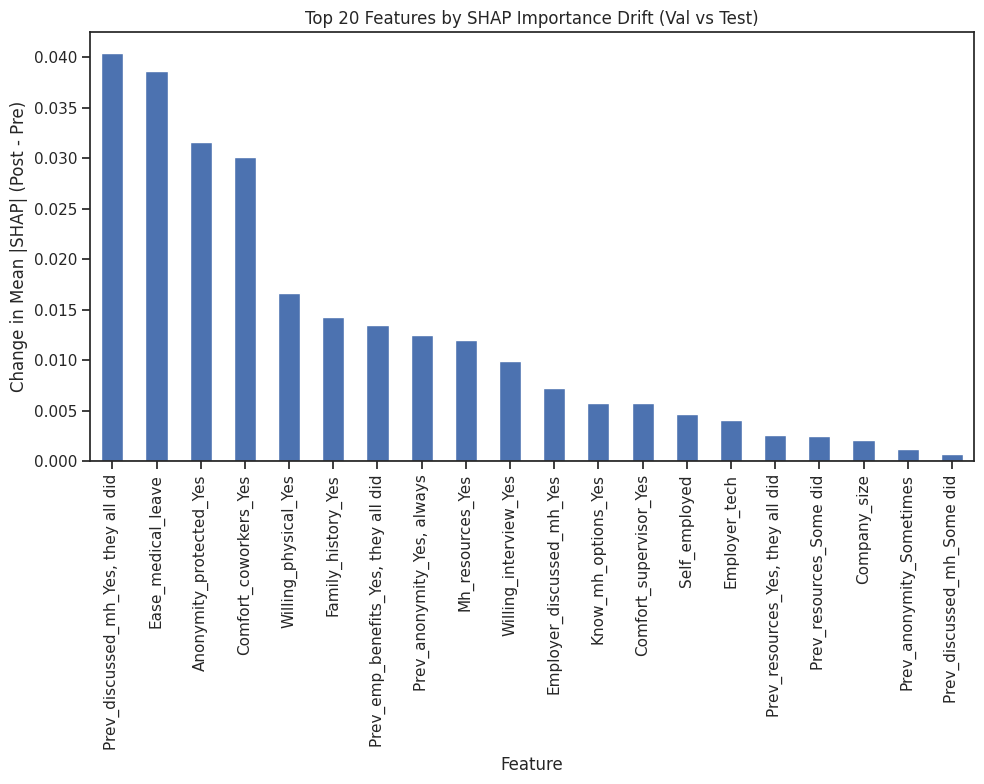

In [280]:
# SHAP drift barplot
plt.figure(figsize=(10, 8))
shap_drift_df.set_index('Feature')['SHAP_Drift'].sort_values(ascending=False).head(20).plot(kind='bar')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('Change in Mean |SHAP| (Post - Pre)')
plt.title('Top 20 Features by SHAP Importance Drift (Val vs Test)')
plt.tight_layout()
plt.show()

#### **Pre-shift**

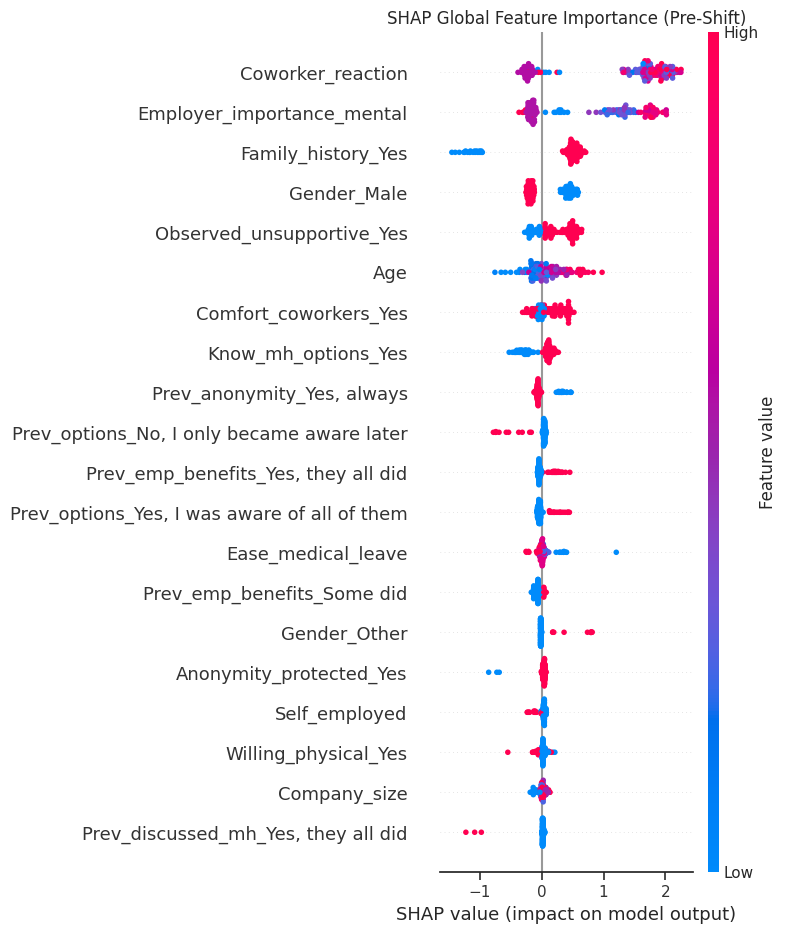

In [281]:
plt.figure(figsize=(10, 10))
plt.title('SHAP Global Feature Importance (Pre-Shift)')

shap.summary_plot(shap_val, X_val, show=False)
plt.tight_layout()
plt.show()

#### **Post-Shift**

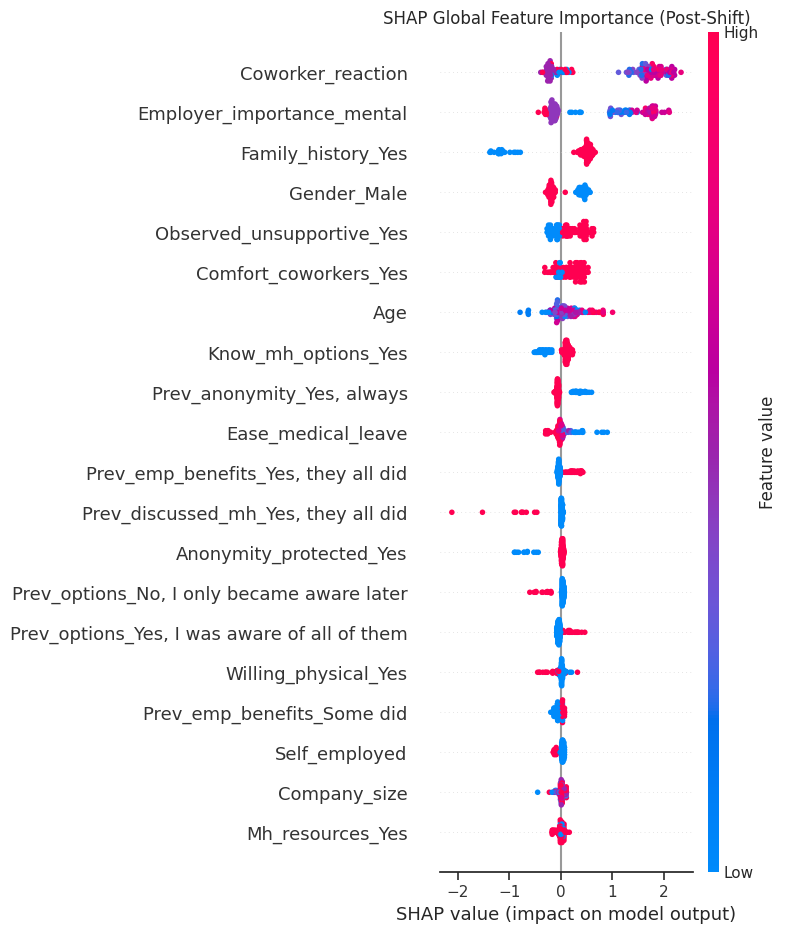

In [282]:
plt.figure(figsize=(10, 10))
plt.title('SHAP Global Feature Importance (Post-Shift)')

shap.summary_plot(shap_test, X_test, show=False)
plt.tight_layout()
plt.show()